# Error Analysis & Compositional Failures

### Understanding Failures

Even with >98% accuracy, analyzing the remaining failures reveals how the model handles compositional phenomena.

**Compositional Phenomena:**
- **Modifiers:** Actions with count ("turn left twice")
- **Nesting:** Repeated action patterns ("turn left turn left")
- **Conjunctions:** Multiple actions joined ("turn left and walk")

### Error Categorization

Examine what types of errors the model makes:

In [138]:
import pandas as pd
import matplotlib.pyplot as plt

standard_errors_df = pd.read_csv('../results/error_breakdown/standard_errors.csv')
standard_errors_df['split'] = 'standard'
fewshot_errors_df = pd.read_csv('../results/error_breakdown/fewshot_errors.csv')
fewshot_errors_df['split'] = 'fewshot'
addprim_jump_errors_df = pd.read_csv('../results/error_breakdown/addprim_jump_errors.csv')
addprim_jump_errors_df['split'] = 'addprim_jump'
filler_split_errors_df = pd.read_csv('../results/error_breakdown/filler_split_errors.csv')
filler_split_errors_df['split'] = 'filler_split'
length_split_errors_df = pd.read_csv('../results/error_breakdown/length_split_errors.csv')
length_split_errors_df['split'] = 'length_split'
template_split_errors_df = pd.read_csv('../results/error_breakdown/template_split_errors.csv')
template_split_errors_df['split'] = 'template_split'

error_df_list = [standard_errors_df, 
                fewshot_errors_df,
                addprim_jump_errors_df,
                filler_split_errors_df,
                length_split_errors_df, 
                template_split_errors_df]

Total errors: 84

Error type distribution:
error_type
REPETITION      62
WRONG ACTION    18
INCOMPLETE       3
WRONG ORDER      1
Name: count, dtype: int64


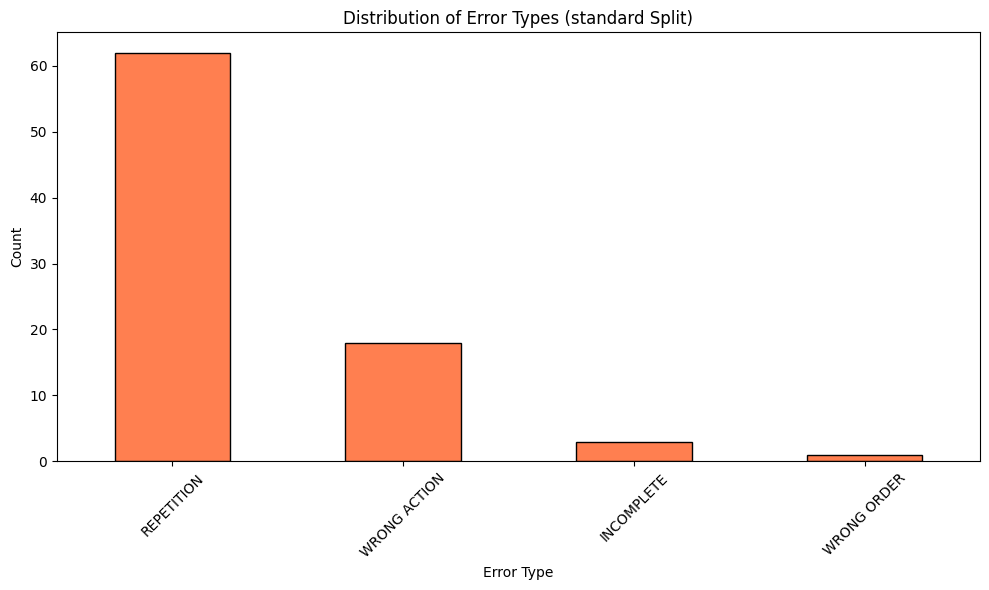

Total errors: 19

Error type distribution:
error_type
REPETITION      13
WRONG ACTION     6
Name: count, dtype: int64


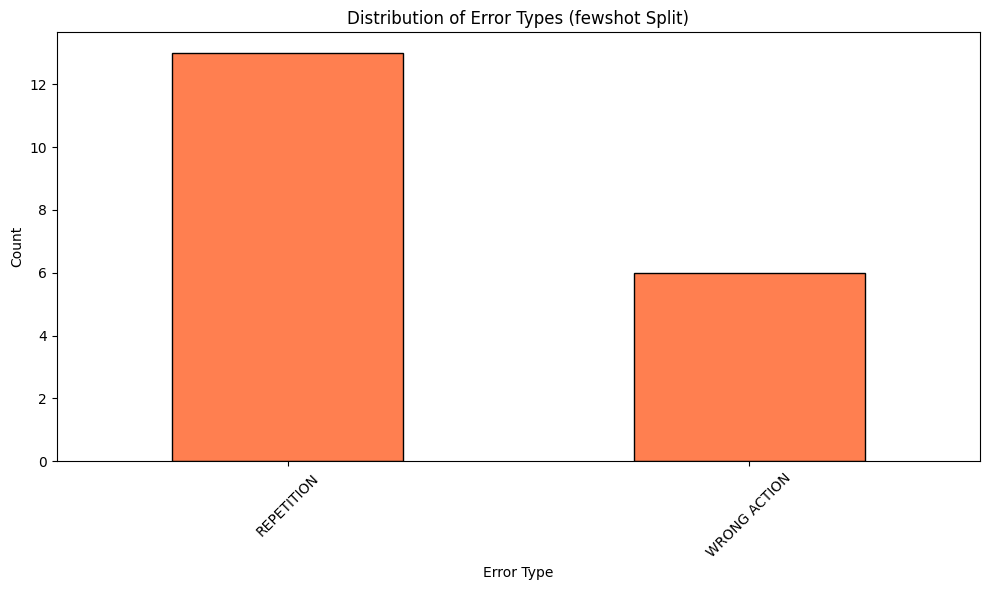

Total errors: 79

Error type distribution:
error_type
REPETITION      53
WRONG ACTION    16
INCOMPLETE       8
WRONG ORDER      2
Name: count, dtype: int64


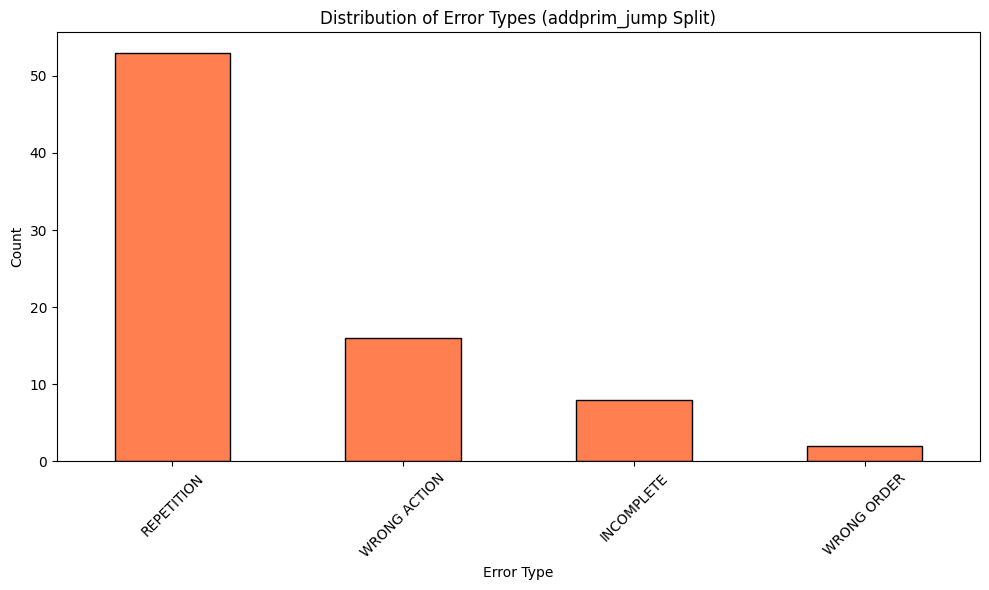

Total errors: 19

Error type distribution:
error_type
REPETITION      13
WRONG ACTION     6
Name: count, dtype: int64


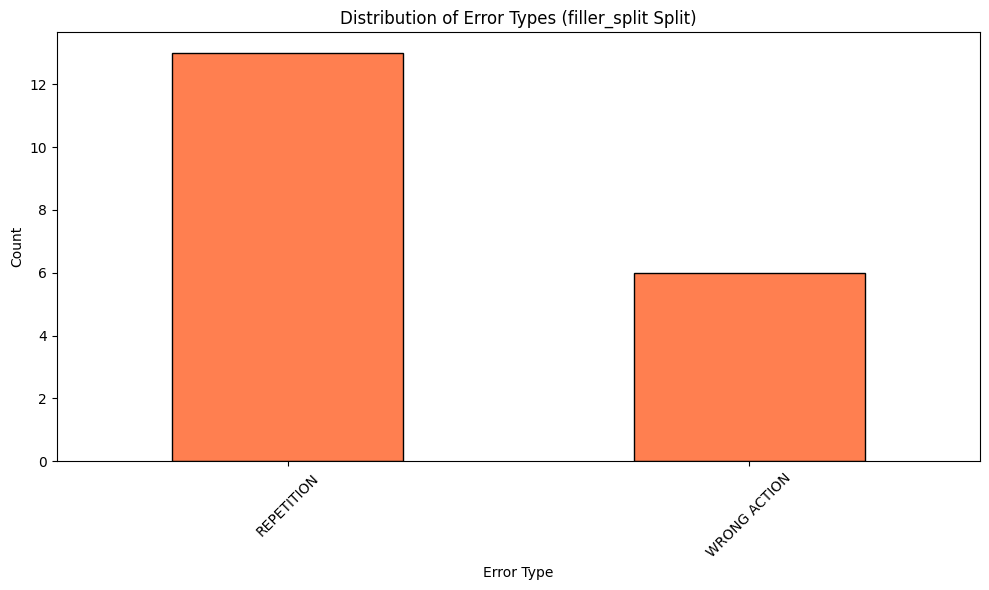

Total errors: 13

Error type distribution:
error_type
WRONG ACTION    11
INCOMPLETE       2
Name: count, dtype: int64


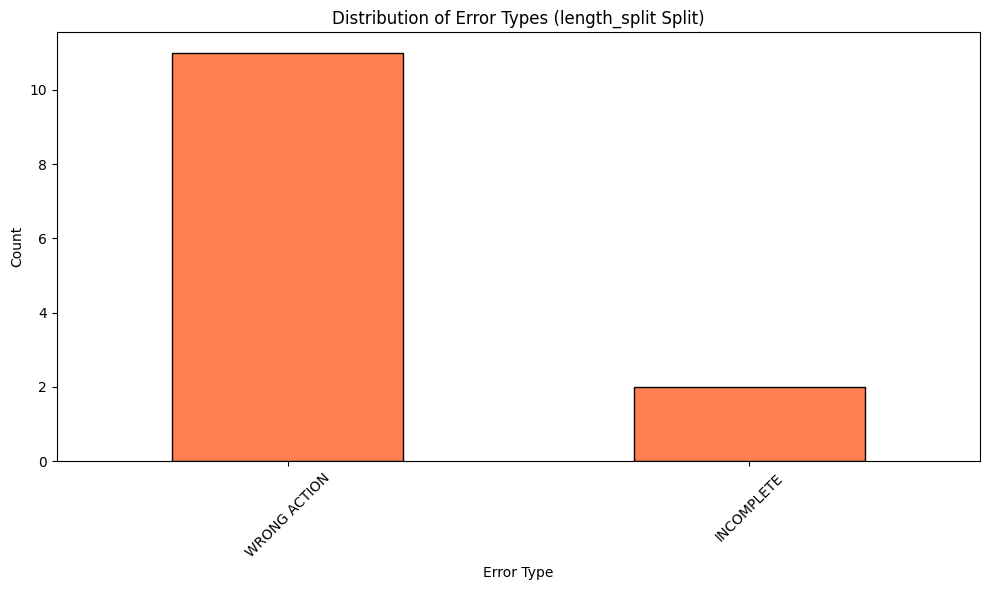

Total errors: 92

Error type distribution:
error_type
REPETITION      71
WRONG ACTION    21
Name: count, dtype: int64


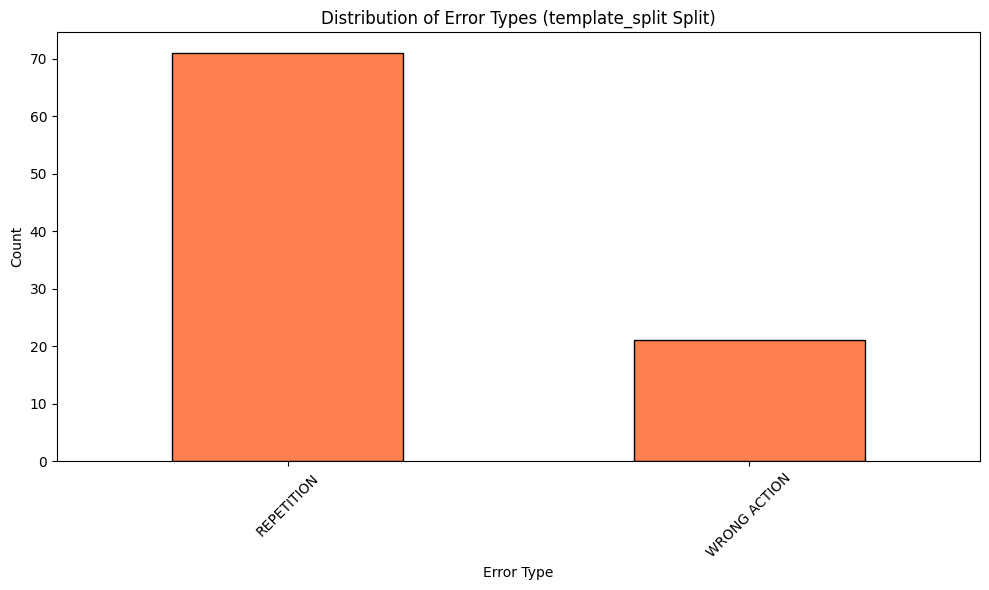

In [139]:
for errors_df in error_df_list:    
    print(f"Total errors: {len(errors_df)}")
    print(f"\nError type distribution:")
    error_counts = errors_df['error_type'].value_counts()
    print(error_counts)
    split_name=errors_df['split'][0]

    plt.figure(figsize=(10, 6))
    error_counts.plot(kind='bar', color='coral', edgecolor='black')
    plt.xlabel('Error Type')
    plt.ylabel('Count')
    plt.title(f'Distribution of Error Types ({split_name} Split)')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(f'../results/error_breakdown/images/{split_name}_error_distribution.png', dpi=150, bbox_inches='tight')
    plt.show()

### Failures by Compositional Phenomena

Which phenomena cause the most failures?

In [140]:
phenomena_path = {
    'standard': '../results/failure_patterns/standard_phenomena_analysis.json',
    'addprim_jump': '../results/failure_patterns/addprim_jump_phenomena_analysis.json',
    'fewshot': '../results/failure_patterns/fewshot_phenomena_analysis.json',
    'filler_split': '../results/failure_patterns/filler_split_phenomena_analysis.json',
    'length_split': '../results/failure_patterns/length_split_phenomena_analysis.json',
    'template_split': '../results/failure_patterns/template_split_phenomena_analysis.json'
}

 Phenomenon  Failures  Failure Rate
   MODIFIER        64      0.761905
    NESTING        80      0.952381
CONJUNCTION        49      0.583333


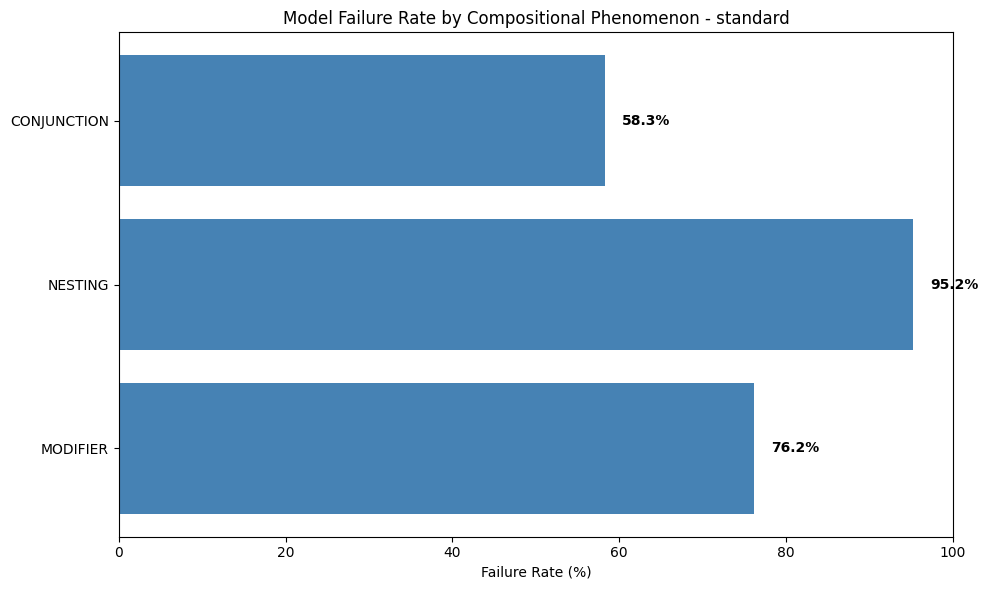

 Phenomenon  Failures  Failure Rate
   MODIFIER        63      0.797468
    NESTING        76      0.962025
CONJUNCTION        39      0.493671


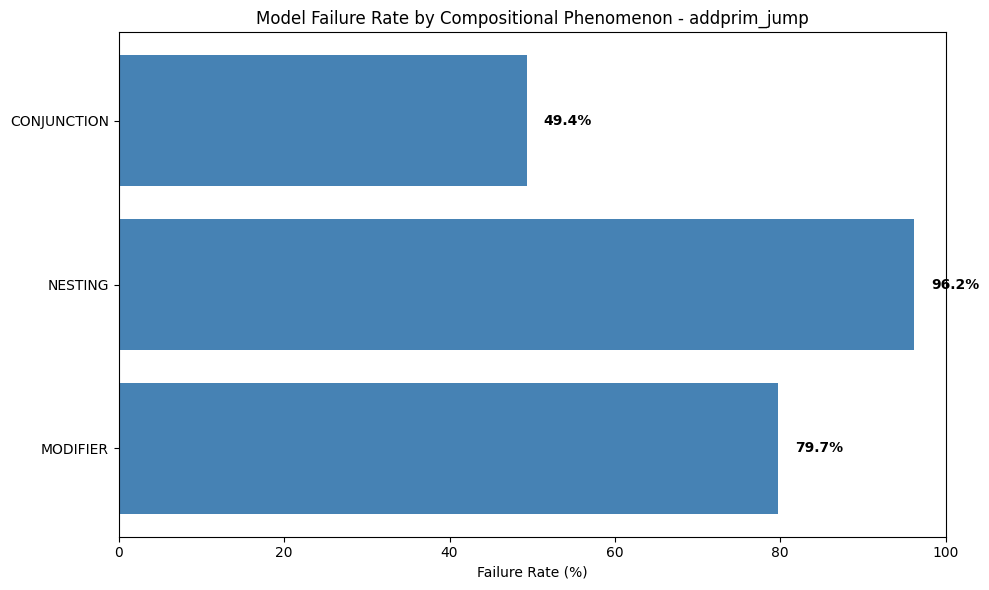

 Phenomenon  Failures  Failure Rate
   MODIFIER        13      0.684211
    NESTING        19      1.000000
CONJUNCTION        11      0.578947


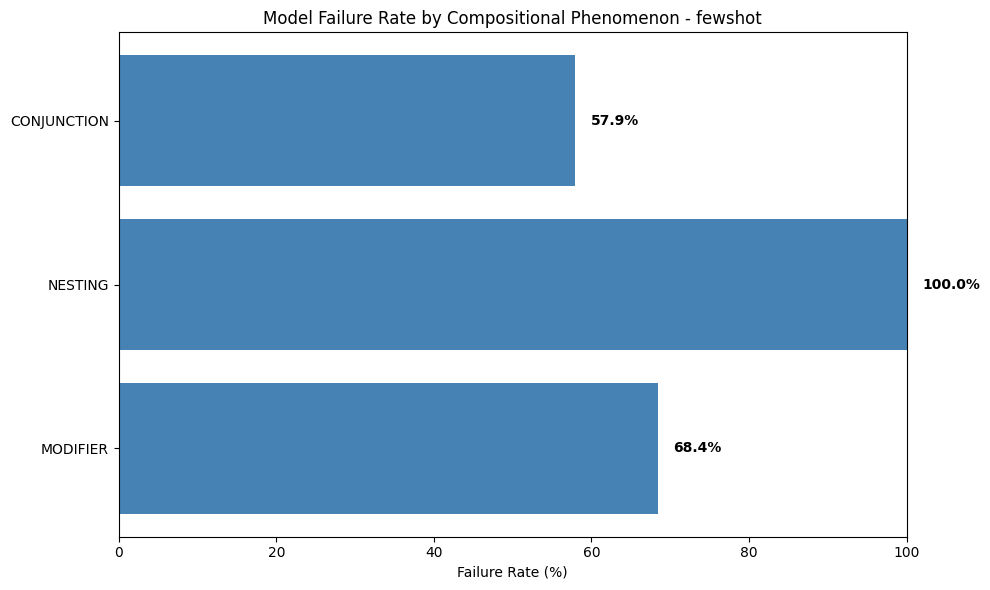

 Phenomenon  Failures  Failure Rate
   MODIFIER        13      0.684211
    NESTING        19      1.000000
CONJUNCTION        11      0.578947


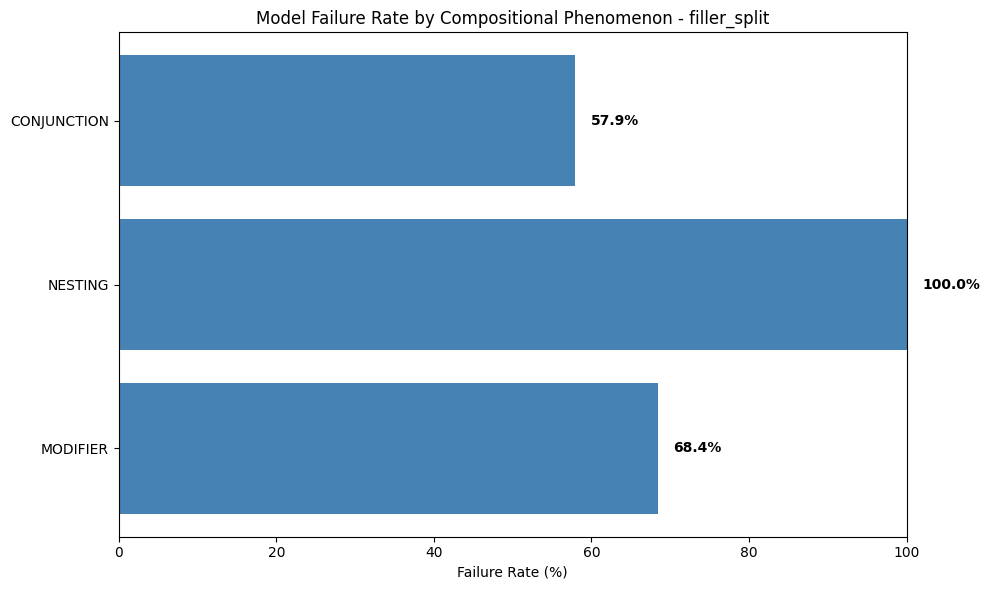

 Phenomenon  Failures  Failure Rate
   MODIFIER        13      1.000000
    NESTING        13      1.000000
CONJUNCTION         6      0.461538


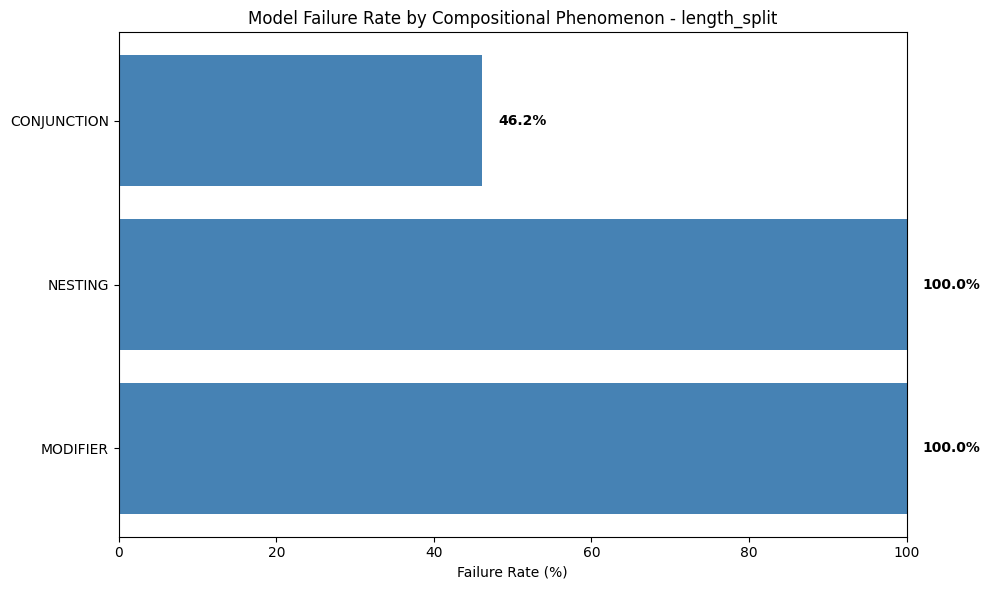

 Phenomenon  Failures  Failure Rate
   MODIFIER        49      0.532609
    NESTING        89      0.967391
CONJUNCTION        53      0.576087


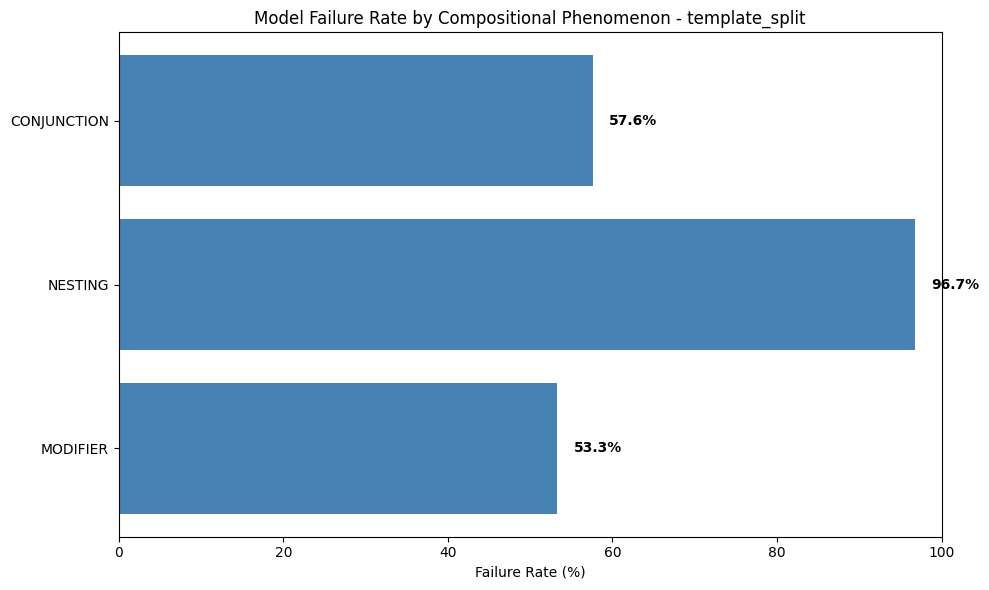

In [141]:
import json
for phenomena_name, path in phenomena_path.items():
    # Load phenomena analysis
    with open(path) as f:
        phenomena = json.load(f)

    phenomena_df = pd.DataFrame([
        {
            'Phenomenon': name,
            'Failures': stats['count'],
            'Failure Rate': stats['rate']
        }
        for name, stats in phenomena.items()
    ])

    print(phenomena_df.to_string(index=False))

    plt.figure(figsize=(10, 6))
    plt.barh(phenomena_df['Phenomenon'], phenomena_df['Failure Rate'] * 100, color='steelblue')
    plt.xlabel('Failure Rate (%)')
    plt.title(f'Model Failure Rate by Compositional Phenomenon - {phenomena_name}')
    plt.xlim([0, 100])
    for i, v in enumerate(phenomena_df['Failure Rate'] * 100):
        plt.text(v + 2, i, f'{v:.1f}%', va='center', fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'../results/failure_patterns/images/{phenomena_name}_phenomena_failure_rate.png', dpi=150, bbox_inches='tight')
    plt.show()

### Failure Examples

Look at specific examples to understand what goes wrong.

In [142]:
# Show examples of each error type
for error_type in error_counts.index[:]:  # Top 3 error types
    print(f"\n{'='*60}")
    print(f"Error Type: {error_type}")
    print(f"{'='*60}")
    
    subset = errors_df[errors_df['error_type'] == error_type].head(3)
    for idx, row in subset.iterrows():
        print(f"\nInput:      {row['input']}")
        print(f"Target:     {row['target']}")
        print(f"Prediction: {row['prediction']}")


Error Type: REPETITION

Input:      look around right after run
Target:     I_RUN I_TURN_RIGHT I_LOOK I_TURN_RIGHT I_LOOK I_TURN_RIGHT I_LOOK I_TURN_RIGHT I_LOOK
Prediction: I_RUN I_TURN_RIGHT I_LOOK I_TURN_RIGHT I_LOOK I_TURN_RIGHT I_LOOK I_TURN_RIGHT I_LOOK I_TURN_

Input:      look around right after turn left
Target:     I_TURN_LEFT I_TURN_RIGHT I_LOOK I_TURN_RIGHT I_LOOK I_TURN_RIGHT I_LOOK I_TURN_RIGHT I_LOOK
Prediction: I_TURN_LEFT I_TURN_RIGHT I_LOOK I_TURN_RIGHT I_LOOK I_TURN_RIGHT I_LOOK I_TURN_RIGHT I_LOOK I_

Input:      look and run around right
Target:     I_LOOK I_TURN_RIGHT I_RUN I_TURN_RIGHT I_RUN I_TURN_RIGHT I_RUN I_TURN_RIGHT I_RUN
Prediction: I_LOOK I_TURN_RIGHT I_RUN I_TURN_RIGHT I_RUN I_TURN_RIGHT I_RUN I_TURN_RIGHT I_RUN I_TURN_

Error Type: WRONG ACTION

Input:      turn opposite right thrice and walk around right
Target:     I_TURN_RIGHT I_TURN_RIGHT I_TURN_RIGHT I_TURN_RIGHT I_TURN_RIGHT I_TURN_RIGHT I_TURN_RIGHT I_WALK I_TUR
Prediction: I_TURN_RIGHT I_TURN_

In [ ]:
split_errors_df = pd.concat([standard_errors_df, 
                             fewshot_errors_df,
                             addprim_jump_errors_df,
                             filler_split_errors_df,
                             length_split_errors_df,
                             template_split_errors_df]).reset_index()
split_errors_df.drop('index', axis=1, inplace=True)
split_errors_df.to_csv('../results/error_breakdown/compositional_analysis/merged_errors.csv', index=False)


In [144]:
summary = split_errors_df.groupby('split').agg({
    'error_type': 'count',
}).rename(columns={'error_type': 'total_errors'})

# Add error type breakdowns
for error_type in split_errors_df['error_type'].unique():
    summary[error_type.lower()] = (
        split_errors_df[split_errors_df['error_type'] == error_type]
        .groupby('split').size()
    )

# Fill NaN with 0
summary = summary.fillna(0).astype(int)

summary.to_csv('../results/error_breakdown/compositional_analysis/summary.csv')

In [158]:
summary.columns

Index(['total_errors', 'wrong action', 'repetition', 'incomplete',
       'wrong order'],
      dtype='str')

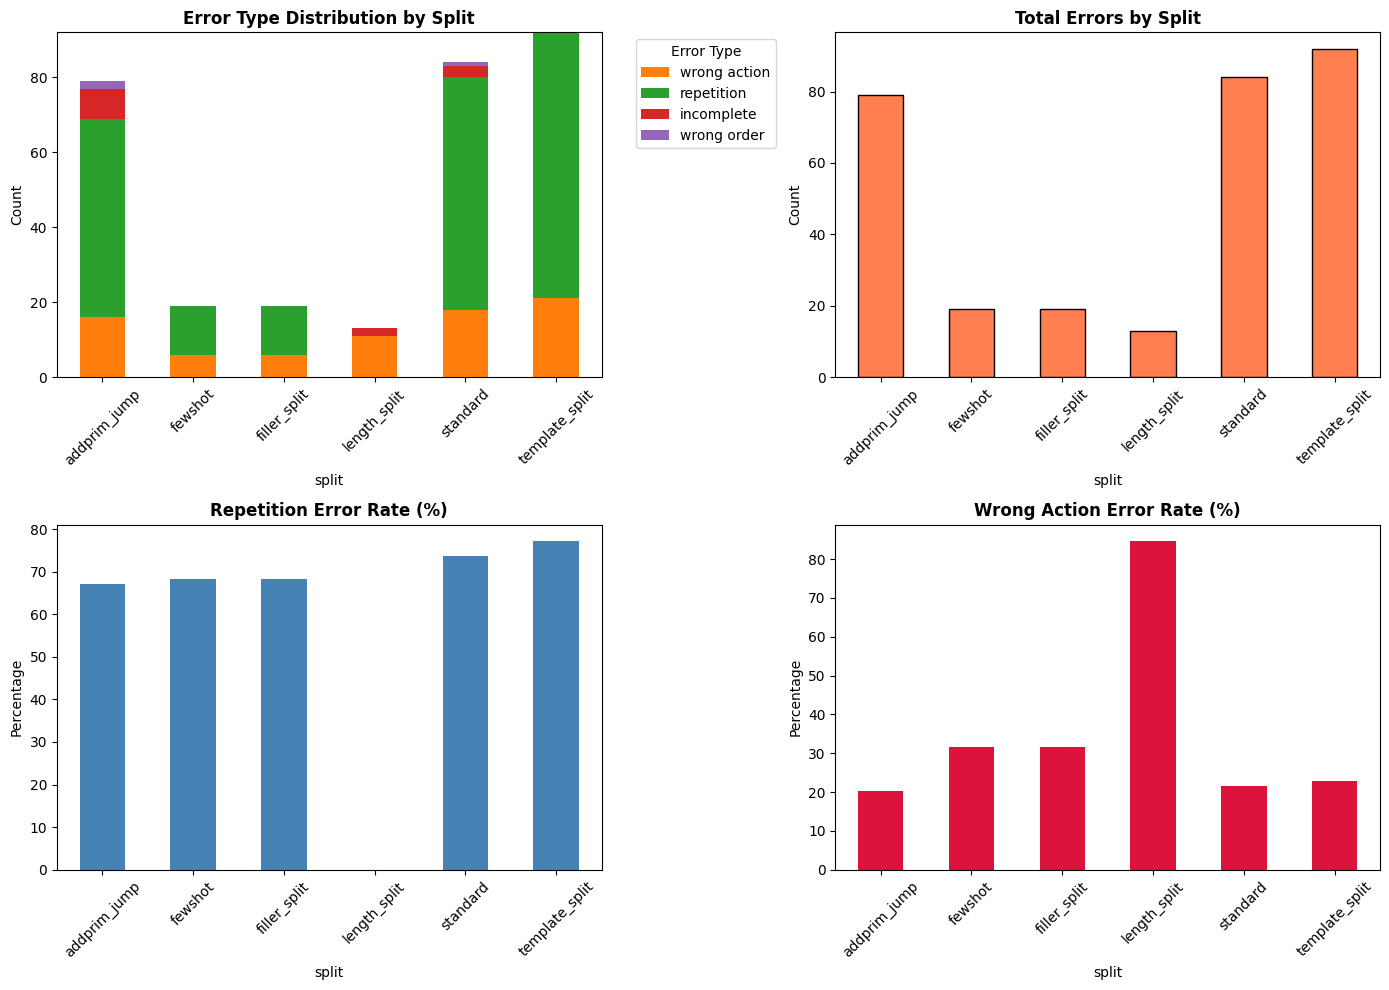

                total_errors  wrong action  repetition  incomplete  \
split                                                                
addprim_jump              79            16          53           8   
fewshot                   19             6          13           0   
filler_split              19             6          13           0   
length_split              13            11           0           2   
standard                  84            18          62           3   
template_split            92            21          71           0   

                wrong order  
split                        
addprim_jump              2  
fewshot                   0  
filler_split              0  
length_split              0  
standard                  1  
template_split            0  


In [159]:
import pandas as pd
import matplotlib.pyplot as plt

# Load summary
summary = pd.read_csv('../results/error_breakdown/compositional_analysis/summary.csv', index_col='split')

# Plot 1: Total errors by split
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Stacked bar chart
summary[['wrong action', 'repetition', 'incomplete',
       'wrong order']].plot(kind='bar', stacked=True, ax=axes[0, 0], 
            color=['#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b'])
axes[0, 0].set_title('Error Type Distribution by Split', fontweight='bold')
axes[0, 0].set_ylabel('Count')
axes[0, 0].legend(title='Error Type', bbox_to_anchor=(1.05, 1), loc='upper left')
axes[0, 0].tick_params(axis='x', rotation=45)

# Total errors
summary['total_errors'].plot(kind='bar', ax=axes[0, 1], color='coral', edgecolor='black')
axes[0, 1].set_title('Total Errors by Split', fontweight='bold')
axes[0, 1].set_ylabel('Count')
axes[0, 1].tick_params(axis='x', rotation=45)

# Repetition rate
(summary['repetition'] / summary['total_errors'] * 100).plot(kind='bar', ax=axes[1, 0], color='steelblue')
axes[1, 0].set_title('Repetition Error Rate (%)', fontweight='bold')
axes[1, 0].set_ylabel('Percentage')
axes[1, 0].tick_params(axis='x', rotation=45)

# Wrong action rate
(summary['wrong action'] / summary['total_errors'] * 100).plot(kind='bar', ax=axes[1, 1], color='crimson')
axes[1, 1].set_title('Wrong Action Error Rate (%)', fontweight='bold')
axes[1, 1].set_ylabel('Percentage')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../results/error_breakdown/error_summary_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(summary)